# Level 2 - Task 1 : Predictive Modeling (Regression)

In [2]:
#Drive Mount +
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Codveda Technologies Data Science task List/Data Set For Task/4) house Prediction Data Set.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Mounted at /content/drive
Shape: (505, 1)

First 5 rows:
  0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00
0   0.02731   0.00   7.070  0  0.4690  6.4210  78...                                             
1   0.02729   0.00   7.070  0  0.4690  7.1850  61...                                             
2   0.03237   0.00   2.180  0  0.4580  6.9980  45...                                             
3   0.06905   0.00   2.180  0  0.4580  7.1470  54...                                             
4   0.02985   0.00   2.180  0  0.4580  6.4300  58...                                             

Data Types:
0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00    object
dtype: object

Missing Values:
0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00    0
dtype: int64


In [3]:
#Preprocessing
# Missing values handle
df.fillna(df.mean(numeric_only=True), inplace=True)

# Categorical encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("Preprocessed Shape:", df.shape)
print(df.head())

Preprocessed Shape: (505, 1)
   0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00
0                                                 23                                              
1                                                 22                                              
2                                                 32                                              
3                                                110                                              
4                                                 27                                              


In [4]:
col_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
             'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B',
             'LSTAT', 'PRICE']

df = pd.read_csv('/content/drive/MyDrive/Codveda Technologies Data Science task List/Data Set For Task/4) house Prediction Data Set.csv',
                 sep='\s+', header=None, names=col_names)

print("All columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head())

# Feature and Target split
target_col = 'PRICE'
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

All columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']
Shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  

Train size: (404, 13)
Test size : (102, 13)


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11507/1504215969.py:6: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', header=None, names=col_names)


# Train All Models

In [5]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)
print(f"Linear Regression  -> MSE: {mse_lr:.2f} | R2: {r2_lr:.4f}")

# Model 2: Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt  = r2_score(y_test, y_pred_dt)
print(f"Decision Tree      -> MSE: {mse_dt:.2f} | R2: {r2_dt:.4f}")

# Model 3: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)
print(f"Random Forest      -> MSE: {mse_rf:.2f} | R2: {r2_rf:.4f}")

Linear Regression  -> MSE: 24.29 | R2: 0.6688
Decision Tree      -> MSE: 10.42 | R2: 0.8580
Random Forest      -> MSE: 7.90 | R2: 0.8923


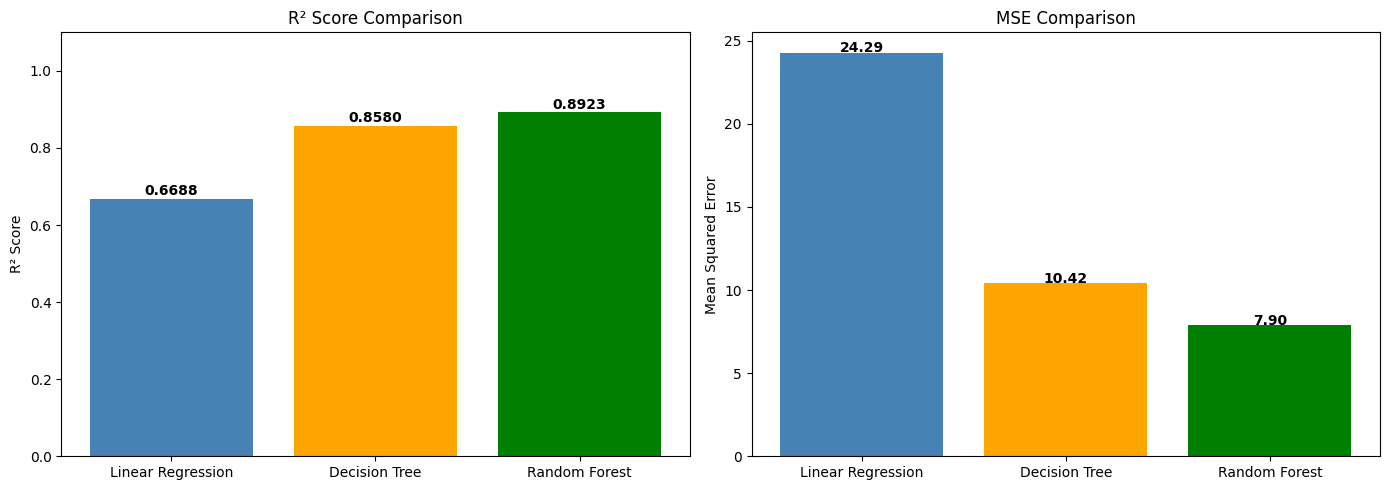

In [6]:
# Model Comparison Chart
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores  = [r2_lr,  r2_dt,  r2_rf]
mse_scores = [mse_lr, mse_dt, mse_rf]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 Score
bars = axes[0].bar(models, r2_scores,
                   color=['steelblue', 'orange', 'green'])
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
for bar, val in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

# MSE
bars2 = axes[1].bar(models, mse_scores,
                    color=['steelblue', 'orange', 'green'])
axes[1].set_title('MSE Comparison')
axes[1].set_ylabel('Mean Squared Error')
for bar, val in zip(bars2, mse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/regression_comparison.png')
plt.show()

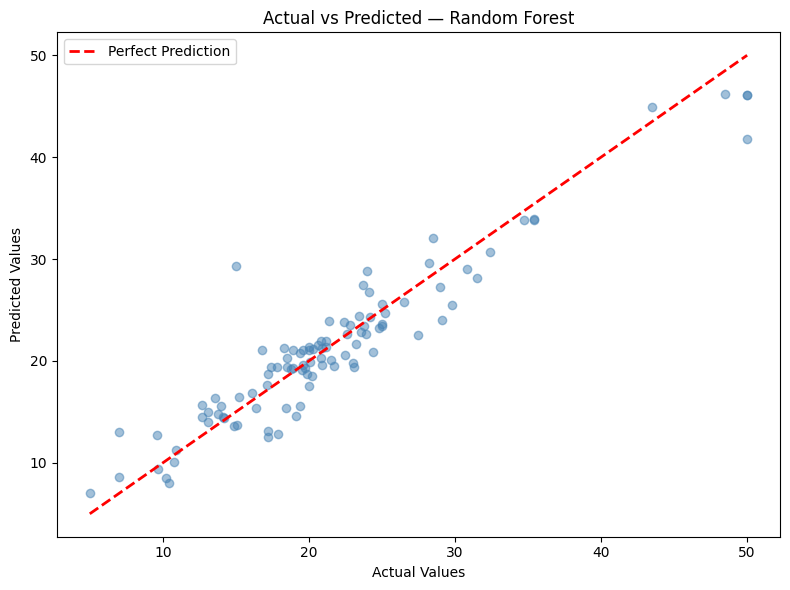

In [7]:
# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted — Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/actual_vs_predicted.png')
plt.show()